# Neural Network for predicting utilization

- <span style="color:green">Code grundsätzlich fertig<span>
- <span style="color:red">Die X-Werte müssen nach dem letzten Run noch korrekt eingesetzt werden<span>
- <span style="color:red">Bei den beiden initialen NNs müssen Epochs und Batchsize Parameter noch angepasst werden, waren nur zu Testzwecken so klein<span>
- <span style="color:red">Ramdom Search/ Hyperparametertuning muss noch durchgelaufen/trainiert werden lassen, dauert vermutlich mehrere Stunden<span>

#### Import all important Librarys

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras import Sequential # sequential model: https://keras.io/guides/sequential_model/
from keras.layers import Dense, Dropout
from keras.regularizers import l2

# supress versioning warnings of keras
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

#### Read in the Data

In [2]:
site1 = pd.read_csv("FINAL1.csv")
site2 = pd.read_csv("FINAL2.csv")

In [3]:
site1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23594 entries, 0 to 23593
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                23594 non-null  int64  
 1   hour                      23594 non-null  int64  
 2   weekday                   23594 non-null  int64  
 3   dayOfMonth                23594 non-null  int64  
 4   month                     23594 non-null  int64  
 5   year                      23594 non-null  int64  
 6   total minutes of parking  23594 non-null  float64
 7   temperature               23594 non-null  float64
 8   cloud_cover               23594 non-null  float64
 9   pressure                  23594 non-null  float64
 10  windspeed                 23594 non-null  float64
 11  precipitation             23594 non-null  float64
 12  felt_temperature          23594 non-null  float64
 13  is_holiday                23594 non-null  int64  
 14  covid 

In [4]:
site1["total minutes of parking"].describe()

count    23594.000000
mean       467.155662
std        958.149017
min          0.000000
25%          0.000000
50%          0.000000
75%        214.683333
max       3120.000000
Name: total minutes of parking, dtype: float64

In [5]:
site2["total minutes of parking"].describe()

count    23594.000000
mean       467.155662
std        958.149017
min          0.000000
25%          0.000000
50%          0.000000
75%        214.683333
max       3120.000000
Name: total minutes of parking, dtype: float64

The target variable is the **total occupied charging minutes per hour**.

We can see that the maximum possible utilization per hour is 3120 minutes which are equivalent to 3120 minutes / 60 minutes = 52 stations.

---

The goal of this prediction task is not only to achieve high statistical accuracy, but to evaluate whether the model is suitable for **operational and strategic decision-making** by a charging hub operator.

More specifically, we want to verify:

1. **Operational Accuracy**  
   How many charging minutes per hour does the model misestimate on average?
   → This determines whether short-term planning (e.g. load management) is feasible.

2. **Relative Accuracy Compared to Site Capacity**  
   How large are the prediction errors relative to the maximum possible utilization?
   → This allows interpretation in percentage terms and comparison across sites.

3. **Explanatory Power**  
   Does the model capture the structural patterns of utilization over time?
   → Important to assess whether predictions are systematic or mostly noise.

---

## NN for Site 1

First we build up a NN for Site 1 with random hyperparameters, to see if a NN is useful for this task

#### Create the target and the features

In [6]:
y = site1["total minutes of parking"]
X = site1.drop(columns=["total minutes of parking"])

#### Split the data

In [7]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

- X_train, y_train → 60%: Training set

- X_val, y_val → 20%: Validation set

- X_test, y_test → 20%: Test set

#### Scale the data

In [8]:
from sklearn.preprocessing import StandardScaler
norm = StandardScaler()
norm.fit(X_train)

X_norm_train = norm.transform(X_train)
X_norm_val = norm.transform(X_val)
X_norm_test = norm.transform(X_test)

#### Build the NN
We use a common neural network architecture from the lecture, but we also include the Keras L2 regularizer to reduce overfitting and improve the model’s generalization to new data.

In [9]:
classifier = Sequential()

classifier.add(Dense(units=64,
                     activation='relu',
                     input_shape=(14,)))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(1, activation='relu'))

classifier.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505 (52.75 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile the NN

In [10]:
classifier.compile(loss='mse',
             optimizer="adam",
             metrics=["mae", "mse"])

#### Train the NN

In [11]:
history = classifier.fit(X_norm_train, y_train,
                            validation_data=(X_norm_val, y_val),
                            epochs=5,
                            batch_size=50)

Epoch 1/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 870214.8750 - mae: 583.6285 - mse: 870214.5000 - val_loss: 678245.0625 - val_mae: 535.3527 - val_mse: 678244.7500
Epoch 2/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 630766.6250 - mae: 498.5526 - mse: 630766.3750 - val_loss: 514678.5312 - val_mae: 446.9828 - val_mse: 514677.9375
Epoch 3/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 365756.7188 - mae: 350.6485 - mse: 365756.1875 - val_loss: 235829.5938 - val_mae: 254.6166 - val_mse: 235828.9531
Epoch 4/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 219003.7969 - mae: 251.5197 - mse: 219003.2188 - val_loss: 188212.7500 - val_mae: 227.7896 - val_mse: 188212.0625
Epoch 5/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 192308.6250 - mae: 230.2806 - mse: 192307.9219 - val_loss: 172008.9688 - val_mae: 211.0359 - val_mse: 172008.3281


#### Results of the NN

In [12]:
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,870214.875000,583.628540,870214.500000,678245.06250,535.352661,678244.750000
1,630766.625000,498.552551,630766.375000,514678.53125,446.982849,514677.937500
2,365756.718750,350.648529,365756.187500,235829.59375,254.616577,235828.953125
3,219003.796875,251.519653,219003.218750,188212.75000,227.789597,188212.062500
4,192308.625000,230.280624,192307.921875,172008.96875,211.035858,172008.328125


In [13]:
root_metrics_df = history_df[["mse", "val_mse"]].apply(np.sqrt)
root_metrics_df.rename({"mse":"rmse", "val_mse":"val_rmse"}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,932.852882,823.556161
1,794.208017,717.410578
2,604.777800,485.622233
3,467.977797,433.834142
4,438.529271,414.738867


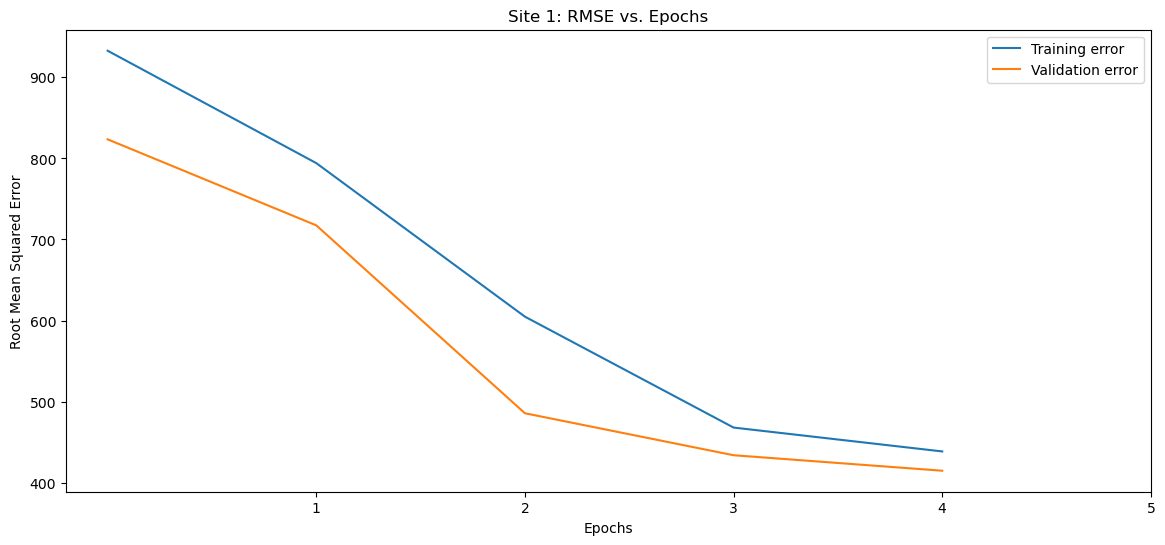

In [14]:
plt.figure(figsize=(14,6), dpi=100)

plt.plot(root_metrics_df["rmse"], label = 'Training error')
plt.plot(root_metrics_df["val_rmse"], label = 'Validation error')

plt.xlabel("Epochs")
plt.ylabel("Root Mean Squared Error")

plt.xticks(range(1,6))
plt.legend()
plt.title("Site 1: RMSE vs. Epochs")

plt.show()

#### Evaluate Performance on Test Set regarding our performance criterions.

In [15]:
y_pred = classifier.predict(X_norm_test)

148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

MAX_MINUTES_PER_HOUR = 52 * 60
mae_percentage = mae / MAX_MINUTES_PER_HOUR * 100

print(f"MAE: {mae}")
print(f"MAE (in percentage): {mae_percentage}")
print(f"R2: {r2}")

MAE: 214.4349542384197
MAE (in percentage): 6.872915199949349
R2: 0.7993869209349792


The NNfor Site 1 achieves a Mean Absolute Error (MAE) of **X** per hour. This means that, on average, the model misestimates hourly utilization by roughly **X** occupied charging minutes.

Given a maximum theoretical capacity of **3120 minutes per hour** (52 charging stations x 60 minutes), this corresponds to a relative error of **X**.

The R2 score of **X** shows that the model explains over **X** of the observed variance**
in hourly utilization.

## NN for Site 2

We build up the NN for Site 2 similar to the NN from Site 1

In [17]:
y = site2["total minutes of parking"]
X = site2.drop(columns=["total minutes of parking"])

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

norm = StandardScaler()
norm.fit(X_train)

X_norm_train = norm.transform(X_train)
X_norm_val = norm.transform(X_val)
X_norm_test = norm.transform(X_test)

classifier = Sequential()

classifier.add(Dense(units=64,
                     activation='relu',
                     input_shape=(14,)))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
classifier.add(Dropout(0.05))

classifier.add(Dense(1, activation='relu'))

classifier.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505 (52.75 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
classifier.compile(loss='mse',
             optimizer="adam",
             metrics=["mae", "mse"])

In [19]:
history = classifier.fit(X_norm_train, y_train,
                            validation_data=(X_norm_val, y_val),
                            epochs=5,
                            batch_size=50)

Epoch 1/5


284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 866681.6250 - mae: 588.0098 - mse: 866681.2500 - val_loss: 681366.2500 - val_mae: 550.6248 - val_mse: 681366.0625
Epoch 2/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 650194.5625 - mae: 506.8803 - mse: 650194.1875 - val_loss: 568168.2500 - val_mae: 453.9078 - val_mse: 568167.9375
Epoch 3/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 450125.4688 - mae: 385.8440 - mse: 450125.0000 - val_loss: 308643.1562 - val_mae: 298.3003 - val_mse: 308642.5625
Epoch 4/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 246177.3281 - mae: 256.5821 - mse: 246176.5625 - val_loss: 192339.0312 - val_mae: 214.3656 - val_mse: 192338.2344
Epoch 5/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 183267.2812 - mae: 212.4609 - mse: 183266.4844 - val_loss: 160283.3750 - val_mae: 188.5481 - val_mse: 160282.5469


In [20]:
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,866681.625000,588.009827,866681.250000,681366.25000,550.624817,681366.062500
1,650194.562500,506.880310,650194.187500,568168.25000,453.907806,568167.937500
2,450125.468750,385.843994,450125.000000,308643.15625,298.300262,308642.562500
3,246177.328125,256.582062,246176.562500,192339.03125,214.365616,192338.234375
4,183267.281250,212.460907,183266.484375,160283.37500,188.548141,160282.546875


In [21]:
root_metrics_df = history_df[["mse", "val_mse"]].apply(np.sqrt)
root_metrics_df.rename({"mse":"rmse", "val_mse":"val_rmse"}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,930.957169,825.449007
1,806.346196,753.769154
2,670.913556,555.556084
3,496.161831,438.563832
4,428.096349,400.353028


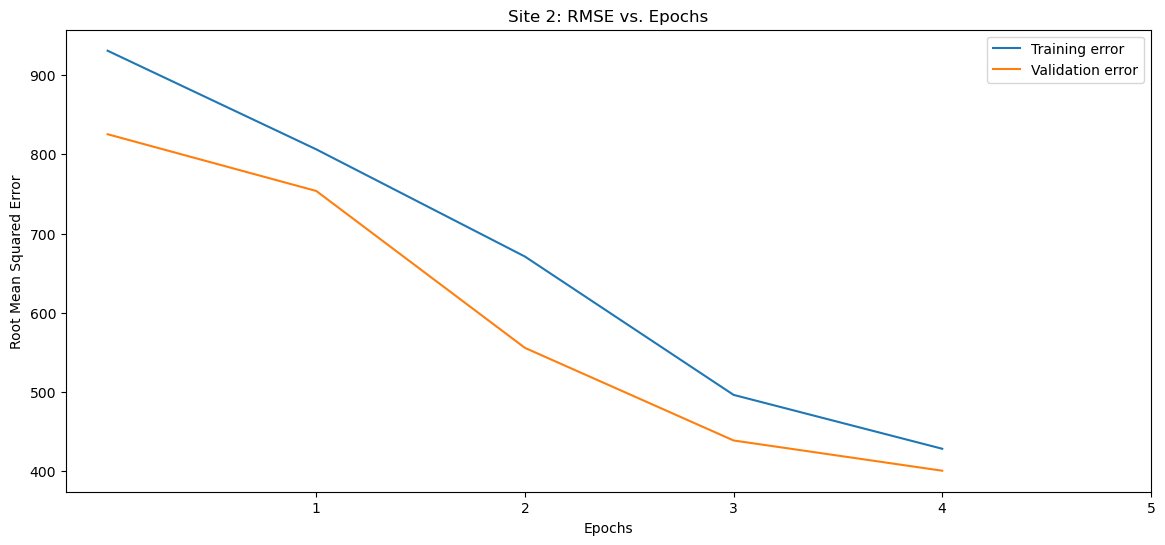

In [22]:
plt.figure(figsize=(14,6), dpi=100)

plt.plot(root_metrics_df["rmse"], label = 'Training error')
plt.plot(root_metrics_df["val_rmse"], label = 'Validation error')

plt.xlabel("Epochs")
plt.ylabel("Root Mean Squared Error")

plt.xticks(range(1,6))
plt.legend()
plt.title("Site 2: RMSE vs. Epochs")

plt.show()

In [23]:
y_pred = classifier.predict(X_norm_test)

148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [24]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

MAX_MINUTES_PER_HOUR = 52 * 60
mae_percentage = mae / MAX_MINUTES_PER_HOUR * 100

print(f"MAE: {mae}")
print(f"MAE (in percentage): {mae_percentage}")
print(f"R2: {r2}")

MAE: 190.5651722898111
MAE (in percentage): 6.107858086211895
R2: 0.8218104794800484


The NNfor Site 2 achieves a Mean Absolute Error (MAE) of **X** per hour. This means that, on average, the model misestimates hourly utilization by roughly **X** occupied charging minutes.

Given a maximum theoretical capacity of **3120 minutes per hour** (52 charging stations x 60 minutes), this corresponds to a relative error of **X**.

The R2 score of **X** shows that the model explains over **X** of the observed variance**
in hourly utilization.

## Overall Performance of the initial NNs

Both neural networks achieve similar performance metrics, with an MAE of around **X**
(**X**% of maximum capacity) and an R2 score of around **X**. This indicates consistent model
behavior across sites and suggests that the underlying utilization dynamics are similarly
structured.

From an operational perspective, an average error of approximately **X** of total capacity
is acceptable for utilization forecasting and decision support. The high R2 values (both values are near 1) further confirm that the models capture systematic demand patterns rather than random fluctuations.

Since the neural network already delivers strong initial results, this modeling approach is confirmed as suitable. In the following steps, we therefore focus on tuning the hyperparameters to further enhance performance.

## Finding the best hyperparamters

To find the best hyperperameters we use Random Search strategy. Random Search has been shown to be
more efficient than grid search in high-dimensional hyperparameter spaces, as it explores a broader range of configurations while remaining computationally tractable.

Because the results for Site 1 and 2 were very similar and our prediction use-case ist only for Site **X** we use the data from this Site

#### Import futher librarys

In [25]:
from keras.callbacks import EarlyStopping
from keras.regularizers import l2
from scipy.stats import uniform, randint
from sklearn.model_selection import ParameterSampler

#### We use the same components as for the NNs above

In [26]:
y = site1["total minutes of parking"]
X = site1.drop(columns=["total minutes of parking"])

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

norm = StandardScaler()
norm.fit(X_train)

X_norm_train = norm.transform(X_train)
X_norm_val = norm.transform(X_val)
X_norm_test = norm.transform(X_test)

#### Build up the NN as a function

In [27]:
def build_NN(
    num_hidden_layers=2,
    units_hidden=32,
    dropout_rate=0.2,
    regularization=0.001
):
    classifier = Sequential()
    classifier.add(Dense(units=units_hidden,
                     activation='relu',
                     input_shape=(14,)))

    for _ in range(num_hidden_layers):
        classifier.add(Dense(
            units_hidden,
            activation="relu",
            kernel_regularizer=l2(regularization)
        ))
        classifier.add(Dropout(dropout_rate))

    classifier.add(Dense(1, activation="relu"))

    classifier.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae", "mse"]
    )

    return classifier


#### Define randomly sampled hyperparameter

The following hyperparameters are randomly sampled to explore a wide range of possible
network configurations while remaining computationally feasible.

In [28]:
distributions = {
    "num_hidden_layers": randint(1, 8),
    "units_hidden": randint(8, 128),
    "dropout_rate": uniform(0.05, 0.5),
    "regularization": uniform(0.0001, 0.01),
    "epochs": randint(20, 100),
    "batch_size": randint(16, 64)
}

param_list = list(ParameterSampler(
    distributions,
    n_iter=10,
    random_state=42
))

#### Random search function, finding the best hyperparameters

In [29]:
best_score = float("inf")
best_params = None
best_model = None

for params in param_list:
    print(f"Testing combination: {params}")

    model = build_NN(
        num_hidden_layers=params["num_hidden_layers"],
        units_hidden=params["units_hidden"],
        dropout_rate=params["dropout_rate"],
        regularization=params["regularization"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_norm_train,
        y_train,
        validation_data=(X_norm_val, y_val),
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        verbose=0,
        callbacks=[early_stopping]
    )

    val_loss = min(history.history["val_loss"])

    if val_loss < best_score:
        best_score = val_loss
        best_params = params
        best_model = model


Testing combination: {'batch_size': 54, 'dropout_rate': np.float64(0.4482714934301164), 'epochs': 34, 'num_hidden_layers': 3, 'regularization': np.float64(0.007896910002727693), 'units_hidden': 28}


KeyboardInterrupt: 

#### Best Hyperparameters Found

In [ ]:
print("Best parameters found:")
print(best_params)
print("Best validation loss:", best_score)

#### Evaluate evaluate performance on test set with the best hyperparameters

In [ ]:
y_pred = classifier.predict(X_norm_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

MAX_MINUTES_PER_HOUR = 52 * 60
mae_percentage = mae / MAX_MINUTES_PER_HOUR * 100

print(f"MAE: {mae}")
print(f"MAE (in percentage): {mae_percentage}")
print(f"R2: {r2}")